## **Description**
**Implemented PCA from scratch and transformed 3D data into 2D using eigenvalue decomposition.**

## **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import plotly.express as px

## **Constructing DataFrame**

In [7]:
np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0], [0,1,0], [0,0,1]])

class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,
                  columns=['feature1', 'feature2', 'feature3'])

df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0], [0,1,0], [0,0,1]])

class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,
                   columns=['feature1', 'feature2', 'feature3'])

df1['target'] = 0

# Combine both dataframes
df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [8]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


## **Plotting 3D Scatterplot**

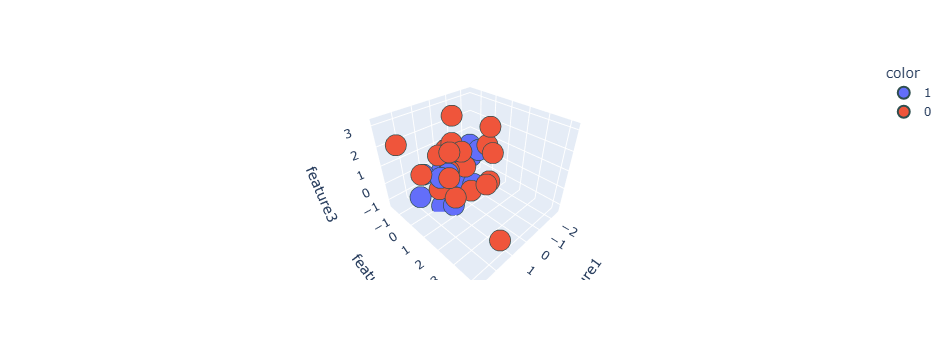

In [13]:
fig = px.scatter_3d(df, x = df['feature1'], y = df['feature2'], z = df['feature3'], 
                    color = df['target'].astype('str'))

fig.update_traces(marker=dict(size=12, 
                              line = dict(width=2, color= 'DarkSlateGrey')
                             ),
                  selector = dict(mode='markers')
                 )
fig.show()

## **Applying PCA**

### **Step 1: Apply Standard Scaling**

In [14]:
scaler = StandardScaler()

df.iloc[:, :3] = scaler.fit_transform(df.iloc[:, :3])

### **Step 2: Find Covariance Matrix**

In [15]:
covariance_matrix = np.cov([df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]]) 
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


### **Step 3: Finding eigenvalues and eigenvectors**

In [16]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [17]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [18]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

### **Step 4: Selecting top k (2) components**

In [21]:
pc = eigen_vectors[:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

### **Transformed DataFrame**

In [22]:
transformed_df = np.dot(df.iloc[:, 0:3], pc.T)
new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


## **Plotting 2D Scatterplot**

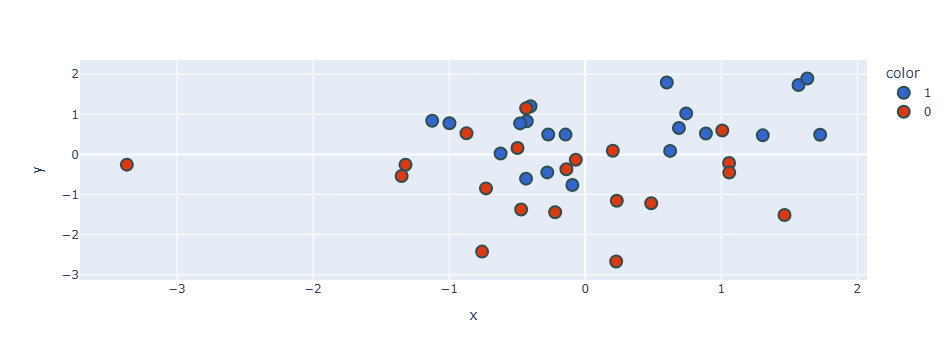

In [27]:
fig = px.scatter(x = new_df['PC1'], 
                 y = new_df['PC2'], 
                 color = df['target'].astype('str'),
                 color_discrete_sequence = px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12, 
                              line = dict(width=2, color= 'DarkSlateGrey')
                             ),
                  selector = dict(mode='markers')
                 )
fig.show()